#Blog writing Agent

Plan of actions
 --> imports
 --> load_dotenv()
 --> all neccessaary instance required(ChatOpenAI)
 --> all pydantic models(Plan , Tasks)
 --> define state 
 --> all functions(nodes : orchestrator,worker,reducer others:fanout)(use structured output required)
 --> logic for md file generation (in the reducer funtion)
 -> define graph
 -> define nodes,edges,conditional edges
 
 -> graph compile 


In [63]:
from __future__ import annotations

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage , HumanMessage 

from langgraph.graph import StateGraph ,START ,END
from langgraph.types import Send
from dotenv import load_dotenv
from pydantic import BaseModel , Field

from typing import Annotated,TypedDict,List
import operator


from pathlib import Path

In [64]:
load_dotenv()

True

In [65]:
llm =ChatOpenAI(model="gpt-4.1-mini")

# print(llm.invoke("hi"))

In [66]:
class Task(BaseModel):
    id: int
    title: str
    brief : str = Field(...,description="What to cover")

In [67]:
class Plan(BaseModel):
    blog_title: str
    tasks : List[Task]

In [68]:
class State(TypedDict):
    topic: str
    plan: Plan
    sections: Annotated[List[str],operator.add]
    final: str

In [69]:
# orchestrator node
def orchestrator(state: State) -> dict:

    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content=(
                    "Create a blog plan with 5-7 sections on the following topic."
                )
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )
    return {"plan": plan}

In [70]:
# define fanout to create worker nodes according to the needs
def fanout(state: State):
    return [Send("worker", {"task": task, "topic": state["topic"], "plan": state["plan"]})
            for task in state["plan"].tasks]

In [71]:
#worker node
def worker(payload: dict) -> dict:

    # payload contains what we sent
    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    blog_title = plan.blog_title

    section_md = llm.invoke(
        [
            SystemMessage(content="Write one clean Markdown section."),
            HumanMessage(
                content=(
                    f"Blog: {blog_title}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Brief: {task.brief}\n\n"
                    "Return only the section content in Markdown."
                )
            ),
        ]
    ).content.strip()

    return {"sections": [section_md]}

In [76]:
# reducer node
import re
from pathlib import Path

def reducer(state: State) -> dict:
    
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"

 
    clean_name = re.sub(r'[^\w\s-]', '', title).strip().lower()
    clean_name = clean_name.replace(" ", "_")

    filename = f"{clean_name}.md"   # 👈 FORCE .md

    output_path = Path(filename)

    print("Saving as:", filename)

    output_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}

In [77]:
# defining graph and nodes

g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)



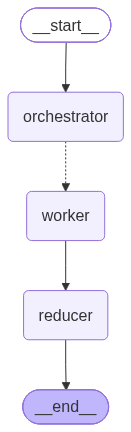

In [74]:
# defining edges

g.add_edge(START, "orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()

app



In [80]:
app.invoke({"topic":"Self attention in Transformers|","sections":[]})

{'topic': 'Self attention in Transformers|',
 'plan': Plan(blog_title='Understanding Self-Attention in Transformers', tasks=[Task(id=1, title='Introduction to Transformers and Self-Attention', brief='Provide an overview of Transformer architecture and introduce the concept of self-attention as a core mechanism.'), Task(id=2, title='The Mechanism of Self-Attention', brief='Explain how self-attention works, including how queries, keys, and values are computed and used to weigh input tokens.'), Task(id=3, title='Mathematical Formulation of Self-Attention', brief='Dive into the formulas underlying self-attention, detailing dot-product attention and scaling factors.'), Task(id=4, title='Multi-Head Self-Attention', brief='Describe the concept of multi-head attention, its benefits, and how it enables the model to capture different representation subspaces.'), Task(id=5, title='Applications and Impact of Self-Attention', brief='Discuss how self-attention improves tasks like machine translation